# Partie V : Votre étude

Réalisez votre propre étude par binôme :
- en modifiant les bases de test et/ou d'apprentissage c'est-à-dire en créant  votre propre base d'apprentissage et votre base de test à partir du corpus et des voix et bruits que vous aurez enregistrés
- en rajoutant davantage de classes (jusqu'à 13 ordres vocaux disponibles) 
- en utilisant d'autres méthodes de réduction de dimension (t-SNE...)
le tout en testant les différentes approches et en interprétant les résultats, à synthétiser sur un rapport en pdf. 


**Paramètres pour enregistrements audio de vos voix perso:**

16 KHz, mono, 16 bits, format *.wav*

Nous avons choisi les mots suivants : *attaque, auto-destruction, Avance, Descend, Esquive, Largue, Leurre, Looping, Monte, Recule, Revient, Tourne-droite, Tourne-Gauche*.

Il sera intéressant de voir si le modèle confond les mots proches comme Largue et Leurre, Recule et Revient, ou Tourne-droite et Tourne-gauche.

Nous avons collaboré avec Arthur et Emeline pour avoir 4 nouvelles voix dans notre dataset.

Nous avons des accents différents :
* Accent Parisien pour Arthur et Victor
* Accent Marseillé pour Emeline
* Accent Toulousain pour Maël

Pour chaque mot, nous avons enregistré 5 versions différentes:

* Avec du bruit
* Elocution normale
* Elocution forte.
* Elocution lente
* Elocution rapide

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import sklearn
import math
import numpy.random as rnd
import seaborn as sns
import librosa
from os import listdir
from os.path import isfile, join
import glob
import re
import random
import torch

random.seed(10)
np.random.seed(10)
torch.cuda.manual_seed_all(10)
torch.manual_seed(10)

## Audio preprocessing

### Get the audios

In [2]:
data = []
lengths = []
label = []
words = ["Attaque", "AutoDestruction", "Avance", "Descends", "Esquive", "Largue", "Leurre", "Looping",
        "Monte", "Recule", "Reviens", "TourneDroite", "TourneGauche"]

for word in listdir("Audios/"):
    if word in words:
        for file_name in listdir(f"Audios/{word}/"):
            if file_name.split(sep=".")[-1] == "wav":
                path = f"Audios/{word}/{file_name}"
                record = librosa.load(path)[0]
                data.append(record)
                lengths.append(record.shape[0])
                label.append(words.index(word))

In [3]:
genres = []
min_duration = None
words = ["Attaque", "AutoDestruction", "Avance", "Descends", "Esquive", "Largue", "Leurre", "Looping",
        "Monte", "Recule", "Reviens", "TourneDroite", "TourneGauche"]
list_genres = ['M', 'F']

for file_name in glob.glob('FichierTest/*.wav'):
    record = librosa.load(file_name)[0]
    data.append(record)
    lengths.append(record.shape[0])
    
    for i, word in enumerate(words):
        if re.search(word.lower(), file_name):
            label.append(i)

fs = librosa.load(file_name)[1] # Sampling frequency
print(f'The smallest record contains {np.min(lengths)} samples, and the sample frequency is {fs} Hz')
print(f'The longest record contains {np.max(lengths)} samples, and the sample frequency is {fs} Hz')

The smallest record contains 8193 samples, and the sample frequency is 22050 Hz
The longest record contains 63504 samples, and the sample frequency is 22050 Hz


In [4]:
print(len(data))
print(len(label))

314
314


### Choose the length of audios

Prendre le min semble problèmatique à cause des élocutions lentes.
En prenant le max on a de mauvais resultats.

{'bodies': [<matplotlib.collections.PolyCollection at 0x7f8a226e17f0>],
 'cmaxes': <matplotlib.collections.LineCollection at 0x7f8a226daa60>,
 'cmins': <matplotlib.collections.LineCollection at 0x7f8a226e3a90>,
 'cbars': <matplotlib.collections.LineCollection at 0x7f8a226e3dc0>}

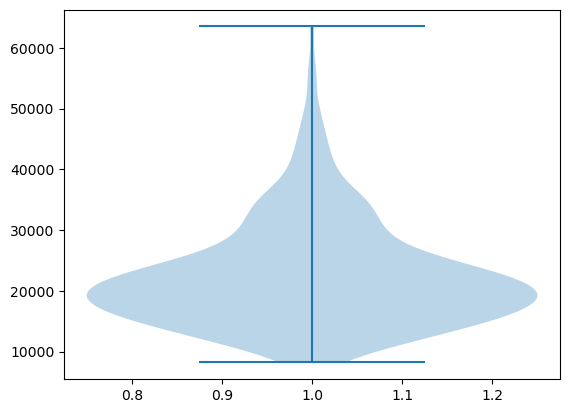

In [5]:
plt.violinplot(lengths)

In [6]:
np.mean(lengths)

22619.503184713376

On a pas mit de blanc dans les audios, on ne souhaite donc pas raccourcir les audios, cela reviendrait à couper les mots. On va donc utiliser du padding pour se ramener à la taille de 

In [7]:
max_duration = int(np.max(lengths))
#max_duration = int(np.round(np.mean(lengths)))

print(max_duration)

63504


In [8]:

""" Si la durée est supérieure à size """
def trim(record):
    half_duration = max_duration//2

    # First, we compute the barycenter of energy along time. We interpret it as the moment when the word appears
    barycenter = int(np.floor(np.multiply(np.power(record,2),np.arange(0,record.shape[0],1)).sum()/np.power(record,2).sum()))

    # Second, we adjust the barycenter to be in the index range
    if barycenter-half_duration < 0:
        barycenter += half_duration-barycenter
    if barycenter+half_duration >= record.shape[0]:
        barycenter -= barycenter+half_duration - record.shape[0]
    
    # Finally, we trim the recording around the barycenter 
    return record[barycenter-half_duration:barycenter+half_duration]

""" Si la durée est inférieure à size 
    On veut ajouter du padding mais toujours avoir le barycentre du signal au centre comme pour trim.
"""
def padding(record):
    
    barycenter = int(np.floor(np.multiply(np.power(record,2),np.arange(0,record.shape[0],1)).sum()
                              /np.power(record,2).sum()))
    
    pad_before = max_duration//2 - barycenter
    
    if pad_before < 0:
        record = record[-pad_before:]
        print(f"b{pad_before}")
        pad_before = 0
    
    pad_after = max_duration - pad_before - len(record)
    
    if pad_after < 0:
        record = record[:pad_after]
        print(f"f{pad_after}")
        pad_after = 0
    """#half_record_size = len(record)//2
    half_size = max_duration // 2
    #start = half_size - half_record_size
    start = max(0, half_size - barycenter)
    end = start + len(record)
    if end > len(output):
        start-= end - len(output)
        end = len(output)
        
    output[start : end] = record"""
    #return np.pad(record, (pad_before, pad_after), mode='constant', constant_values=0)
    return np.pad(record, (pad_before, pad_after), mode='wrap')

def audio_preprocess(record):
    return padding(record)
    """if len(record) > max_duration:
        return trim(record)
    elif len(record) < max_duration:
        return padding(record)
    return record"""    


In [9]:
X = np.empty((len(data),max_duration))
for i in range(len(data)):
    X[i,:] = audio_preprocess(data[i])

y = np.array(label)
print(f'Shape of inputs X is{X.shape} and size of targets class is {y.shape}')

f-5338
f-14
f-13269
Shape of inputs X is(314, 63504) and size of targets class is (314,)


## Transformation des données d'entrée

In [10]:
from sklearn.base import BaseEstimator, TransformerMixin

def med_std(array):
    std = np.std(array, axis=-1)
    med = np.median(array, axis=-1)
    return np.concatenate([std, med], axis=-1)


class MFCC(BaseEstimator, TransformerMixin):
    
    def __init__(self, time_statistics, n_mfcc):
        self.time_statistics = time_statistics
        self.n_mfcc = n_mfcc
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        MFCC_X = librosa.feature.mfcc(y=X, sr=fs, n_mfcc=self.n_mfcc)
        time_stat = self.time_statistics(MFCC_X)
        return time_stat
    
    def __repere__(self):
        print("MFCC")

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

preproc = Pipeline([('mfcc', MFCC(med_std, 10)), ("scaler", StandardScaler())])
transformed_X = preproc.fit_transform(X)

## Split dataset

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=10)

314


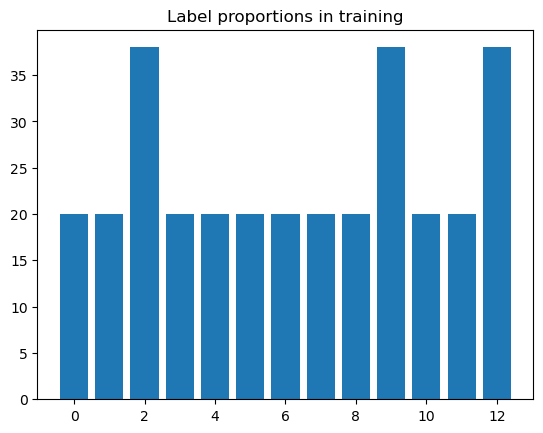

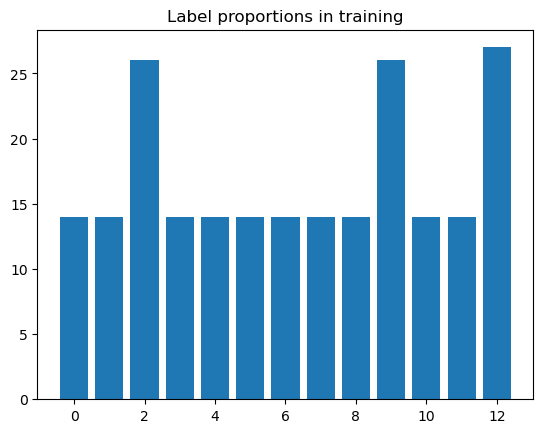

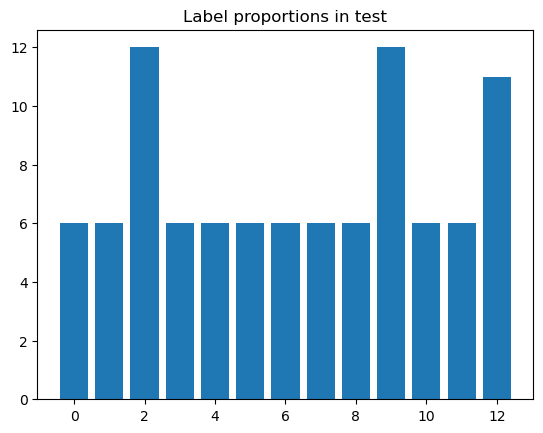

In [13]:
label_list = range(np.max(y)+1)
label_count_train = [np.sum(y_train == i) for i in label_list]
label_count_test = [np.sum(y_test == i) for i in label_list]
label_count_original = [np.sum(y == i) for i in label_list]
print(np.sum(label_count_original))

plt.bar(label_list, label_count_original)
plt.title("Label proportions in training")
plt.show()
    
plt.bar(label_list, label_count_train)
plt.title("Label proportions in training")
plt.show()

plt.bar(label_list, label_count_test)
plt.title("Label proportions in test")
plt.show()

## Fontions auxilières

In [14]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, labels=None, title="Confusion Matrix"):
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=labels if labels else np.unique(y_true), 
                yticklabels=labels if labels else np.unique(y_true))
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    print(f"f1 micro: {np.round(f1_score(y_true, y_pred, average='micro'), 3)}")
    print(f"f1 macro: {np.round(f1_score(y_true, y_pred, average='macro'), 3)}")
    print(f"f1 weighted: {np.round(f1_score(y_true, y_pred, average='weighted'), 3)}")
    print(f"f1 accuracy: {np.round(accuracy_score(y_true, y_pred), 3)}")
    #return matrix

## Regression Multinomiale

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

In [16]:
def feature_grid_search():
    estimators = [('feature', MFCC(med_std, 0)), ("scaler", StandardScaler()), 
                  ('regression', LogisticRegression(solver="saga", max_iter=500, class_weight="balanced"))]
        
    pipeline = Pipeline(estimators)

    params = {'scaler': [StandardScaler(), RobustScaler()],
             'feature__n_mfcc': [10, 50, 100],
             'regression__penalty': ["l1", "l2", None],
             'regression__C': [0.1, 1, 10]}
    
    feature_grid_search = GridSearchCV(pipeline, params, scoring="f1_micro", cv=2, verbose=1, n_jobs=10)
    return feature_grid_search


"""MFCC_CV_scaled = feature_grid_search()
MFCC_model_scaled = MFCC_CV_scaled.fit(X, y)
print(f"Best parameters for scaled MFCC: {MFCC_model_scaled.best_params_}")
print(f"Best score for scaled MFCC: {MFCC_model_scaled.best_score_}")"""

"""
The grid search returns :
Fitting 2 folds for each of 54 candidates, totalling 108 fits
Best parameters for scaled MFCC: {'feature__n_mfcc': 10, 'regression__C': 1, 'regression__penalty': 'l2', 'scaler': StandardScaler()}
Best score for scaled MFCC: 0.5254777070063694

"""

"\nThe grid search returns :\nFitting 2 folds for each of 54 candidates, totalling 108 fits\nBest parameters for scaled MFCC: {'feature__n_mfcc': 10, 'regression__C': 1, 'regression__penalty': 'l2', 'scaler': StandardScaler()}\nBest score for scaled MFCC: 0.5254777070063694\n\n"

In [17]:
#model = MFCC_model_scaled.best_estimator_
model = Pipeline([('feature', MFCC(med_std, 10)), ("scaler", StandardScaler()), 
                  ('regression', LogisticRegression(solver="saga", max_iter=1000, class_weight="balanced"))])

model.fit(X_train, y_train)
prediction = model.predict(X_test)

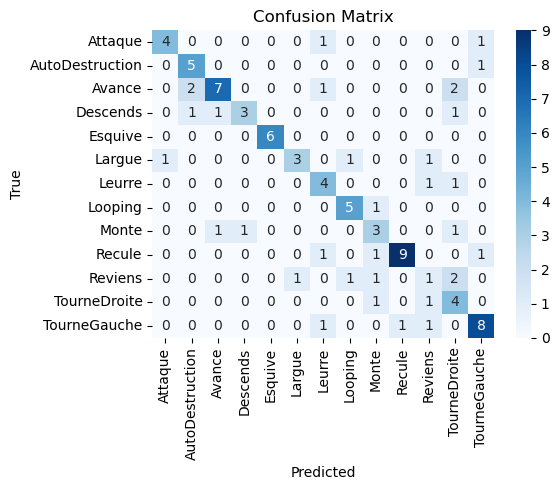

f1 micro: 0.653
f1 macro: 0.639
f1 weighted: 0.657
f1 accuracy: 0.653


In [18]:
ConfusionMatrix_best_FFT_scaled = plot_confusion_matrix(y_test, prediction,
                                  labels=words, title="Confusion Matrix")

## Réseaux de neurones

### Fonction d'entrainement

In [30]:
from copy import deepcopy
from tqdm import tqdm

def train_loop(X_test, model, num_epochs, dataloader, weight_decay=0.001):
    X_test = torch.tensor(X_test, device=device)
    best_model = None
    best_value = np.inf
    best_model_index = 0
    
    result_test_loss = []
    result_train_loss=[]

    lr = 0.001
    optimizer = torch.optim.AdamW(model.parameters(), lr, weight_decay=weight_decay)
    loss = torch.nn.CrossEntropyLoss()

    for epoch in tqdm(range(num_epochs)):

        model.train()
        train_losses = []
        for data, label in dataloader:
            # compute loss
            prediction = model(data)
            train_loss = loss(prediction, label)

            # backpropagation and optimization steps
            train_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # save loss
            train_losses.append(train_loss)

        model.eval()
        test_losses = []
        for i in range(X_test.shape[0]):
            test_losses.append(loss(model(X_test[i]), y_test[i]))

        result_train_loss.append(torch.stack(train_losses).mean().item())
        mean_test_loss = torch.stack(test_losses).mean().item()
        result_test_loss.append(mean_test_loss)
        
        # Early stopping
        if mean_test_loss < best_value:
            best_value = mean_test_loss
            best_model = deepcopy(model)
            best_model_index = epoch
    
    print(f"Early stop : restoring model parameters to epoch {best_model_index}.")
        
    return best_model, result_train_loss, result_test_loss

### Setup

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [21]:
import torch

preproc = Pipeline([('mfcc', MFCC(med_std, 10)), ("scaler", StandardScaler())])
transformed_X = preproc.fit(X)

#X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.3, stratify=y, random_state=10)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=10)
#X_train = torch.tensor(X_train, device=device)
X_test = torch.tensor(preproc.transform(X_test), device=device).float()
y_train = torch.tensor(y_train, device=device)
y_test = torch.tensor(y_test, device=device)

In [22]:
print(X_train.shape)

(219, 63504)


Finalement c'est mieux d'avoir linear en sortie (la sigmoide est dans la loss donc mettre Relu reviendrait à composer relu et sigmoide ce qui n'est pas terrible).
Le dataset est déséquilibré et plus grand. Il nous faut donc creer un balanced dataloader

In [23]:
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler, Dataset
from audiomentations import Compose, AddGaussianNoise, TimeStretch, PitchShift, Shift

augment = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.5),
    TimeStretch(min_rate=0.8, max_rate=1.25, p=0.5),
    PitchShift(min_semitones=-4, max_semitones=4, p=0.5),
    Shift(min_fraction=-0.5, max_fraction=0.5, p=0.5)
])

class CustomImageDataset(Dataset):
    def __init__(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train

    def __len__(self):
        return len(self.X_train)

    def __getitem__(self, idx):
        audio = X_train[idx, :]
        X_i = torch.tensor(preproc.transform(augment(np.array([audio], dtype=np.float32), sample_rate=16000))[0], device=device)
        print()
        return X_i, y_train[idx]


dataset = CustomImageDataset(X_train, y_train)

In [24]:
print(dataset[0][0].shape)
print(dataset[0][1])


torch.Size([20])

tensor(1, device='cuda:0')


In [25]:
class_counts = torch.bincount(y_train)
class_weights = 1 / class_counts
print(class_counts)
print(class_weights)
sample_weights = class_weights[y_train]

tensor([14, 14, 26, 14, 14, 14, 14, 14, 14, 26, 14, 14, 27], device='cuda:0')
tensor([0.0714, 0.0714, 0.0385, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714, 0.0714,
        0.0385, 0.0714, 0.0714, 0.0370], device='cuda:0')


Creation du sampleur : les classes avec le plus d'individus ont moins de chances d'être tirées au sort. On créé le dataloader à partir du sampleur.

In [26]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
balanced_loader = DataLoader(dataset, batch_size=16, sampler=sampler)

In [27]:
"""class NNClassification(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(in_features=input_dim, out_features=25),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.6),
            torch.nn.Linear(in_features=25, out_features=output_dim),
            #torch.nn.ReLU(),
        )
    
    def forward(self, xb):
        ### the forward method will be called each time you will write model(x). 
        ### It's equivalent to the function predict of sklearn
        return self.network(xb)"""

class NNClassification(torch.nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(in_features=input_dim, out_features=400),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=400, out_features=200),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=200, out_features=100),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(in_features=100, out_features=50),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(in_features=50, out_features=25),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(in_features=25, out_features=output_dim),
            #torch.nn.ReLU(),
        )
    
    def forward(self, xb):
        ### the forward method will be called each time you will write model(x). 
        ### It's equivalent to the function predict of sklearn
        return self.network(xb)

### Training

In [31]:
input_dim = 20
nb_classes = np.max(y) + 1

model = NNClassification(input_dim, nb_classes).to(device).float()
num_epochs = 300

model, result_train_loss, result_test_loss = train_loop(preproc.transform(X_test.cpu().numpy()), model, num_epochs, balanced_loader, weight_decay=1e-3)
plt.plot(result_test_loss, label="test")
plt.plot(result_train_loss, label="train")
plt.legend()
plt.show()

/home/n7student/miniconda3/envs/py3.8/lib/python3.8/site-packages/librosa/util/decorators.py:88: UserWarning: n_fft=2048 is too small for input signal of length=20
  return f(*args, **kwargs)
  0%|                                                   | 0/300 [00:00<?, ?it/s]

  0%|▏                                        | 1/300 [00:30<2:32:20, 30.57s/it]

  1%|▎                                        | 2/300 [00:59<2:26:53, 29.58s/it]

  1%|▎                                        | 2/300 [02:28<6:09:31, 74.40s/it]


RuntimeError: CUDA error: unspecified launch failure
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
X_train_tr = torch.tensor(preproc.transform(X_train), device=device).float()

pred_train = np.argmax(model(X_train_tr).cpu().detach().numpy(), -1)
pred_test = np.argmax(model(X_test).cpu().detach().numpy(), -1)

plot_confusion_matrix(y_train.cpu(), pred_train, labels=words, title="Confusion Matrix in training")
plot_confusion_matrix(y_test.cpu(), pred_test, labels=words, title="Confusion Matrix in test")